# Program 1 : Image Segmentation


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.measure import label

Total Connected Components: 96


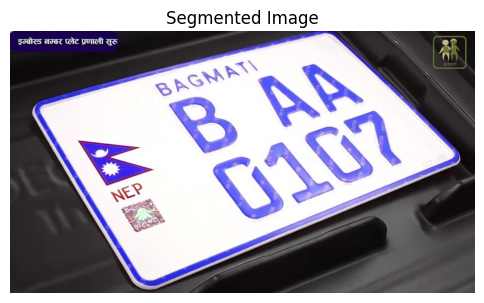

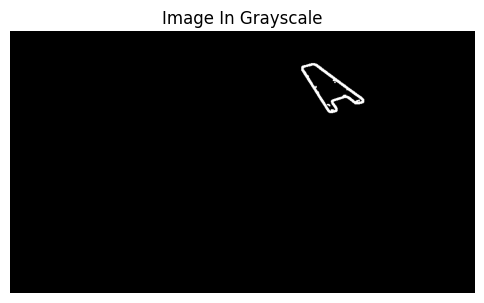

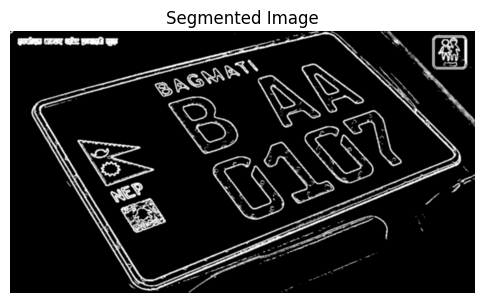

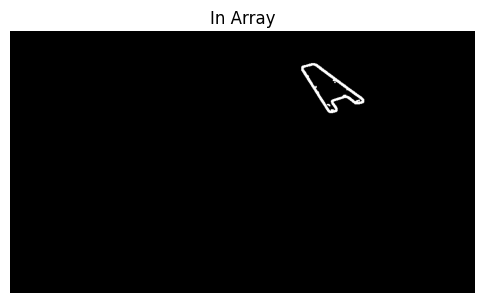

In [17]:
# Read image
im = cv2.imread('/content/number_plate.jpg')

# Convert image to RGB
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Convert image to grayscale
im1 = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

# Median filtering (3x3)
im1 = cv2.medianBlur(im1, 3)

# Sobel edge detection
grad_x = cv2.Sobel(im1, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(im1, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(grad_x**2 + grad_y**2)
BW = (magnitude > 100).astype(np.uint8) # Threshold can be adjusted

# image dimension
imx,imy = BW.shape

# Mask (same as MATLAB)
msk = np.array([
[0, 0, 0, 0, 0],
[0, 1, 1, 1, 0],
[0, 1, 1, 1, 0],
[0, 1, 1, 1, 0],
[0, 0, 0, 0, 0]
], dtype=np.uint8)

# Convolution
B = convolve2d(BW.astype(float), msk.astype(float), mode='same')

# Connected component labeling (8-connectivity)
L = label(B > 0, connectivity=2)
mx = L.max()
print("Total Connected Components:", mx)

# MATLAB extracts component 17
component_number = 17
n1 = np.zeros((imx, imy), dtype=np.uint8)
if component_number <= mx:
  r, c = np.where(L == component_number)
  n1[r, c] = 255
else:
  print(f"Component {component_number} not found.")

#Display Results
plt.figure(figsize=(6, 6))
plt.imshow(n1, cmap='gray')
plt.title('Image In Grayscale')
plt.axis('off')

plt.figure(figsize=(6,6))
plt.imshow(B, cmap='gray')
plt.title("Segmented Image")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(n1, cmap='gray')
plt.title("In Array")
plt.axis("off")
plt.show()




# 2. Pattern Recognition

In [7]:
import cv2
import matplotlib.pyplot as plt

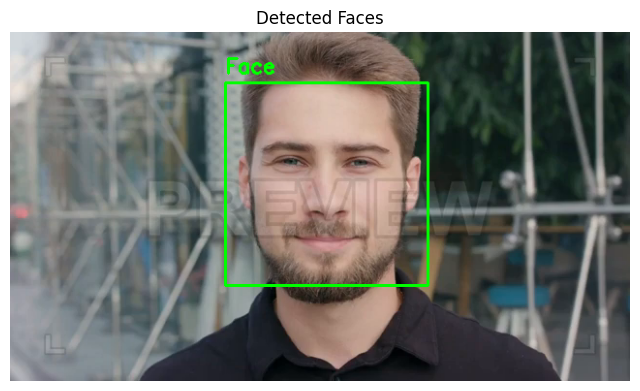

In [8]:
# Load Haar Cascade face detector
face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Open the Video File

video = cv2.VideoCapture('/content/video.mp4')

# Read the first frame
ret, frame = video.read()
if not ret:
  print("Error: Could not read the video.")
  exit()

# Convert frame to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_detector.detectMultiScale(
gray,
scaleFactor=1.1,
minNeighbors=5,
minSize=(30, 30)
)

# Draw rectangles around detected faces
for (x, y, w, h) in faces:
  cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
  cv2.putText(frame, "Face", (x, y - 10),cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0, 255, 0), 2)

# Convert BGR to RGB for Matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Display the result

plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title('Detected Faces')
plt.axis('off')
plt.show()

# Release the Video
video.release()

